# Create UVEX dark-current calibration map FITS

This notebook creates detector-specific dark-current calibration maps for the
UVEX NUV detectors.

Each 4096 × 4096 calibration map contains the dark-current rate for each pixel
in e⁻/pixel/s. The map may either be generated synthetically for provisional
simulations or supplied as a measured detector characterization array.

The resulting FITS files are used by the UVEX ScopeSim detector model.

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from pathlib import Path
import sys


# Path to UVEX calibration code
code_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/code"
)

sys.path.insert(0, str(code_dir))


from detector_calibration import (
    generate_synthetic_dark_current,
    use_dark_current_array,write_dark_current_calibration)

In [2]:
dark_current_map = generate_synthetic_dark_current(
    mean_dark_current=0.01,
    pixel_variation=0.002,
)


# to change to array instead of synthetic:
'''measured_dark_current = np.load("test_dark_current_array.npy")

dark_current_map = use_dark_current_array(
    measured_dark_current
)'''

'measured_dark_current = np.load("test_dark_current_array.npy")\n\ndark_current_map = use_dark_current_array(\n    measured_dark_current\n)'

In [6]:
#####################################################

#### USER MODIFIABLE INPUTS: ####

save_filename = "UVIM_DET_dark_current_test.fits"

output_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/data_files"
)

#####################################################

### Save dark current map as FITS file

#### run for a single detector:

In [7]:
#change to make maps for different detectors
# CAUTION: ensure the detector ID matches your intended detector
DET_ID = 'A1'

write_dark_current_calibration(
    dark_current_map,
    save_filename,
    detector_id=DET_ID,
    output_dir=output_dir,
)

Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/UVIM_DET_dark_current_test.fits
Median DC:   0.010 e-/pixel/s
Mean DC:     0.010 e-/pixel/s
Min DC:      0.000 e-/pixel/s
Max DC:      0.021 e-/pixel/s


#### run for all 9 detectors (only used for provisional mapping and testing):

In [14]:
'''detector_ids = [
    "A1", "A2", "A3",
    "B1", "B2", "B3",
    "C1", "C2", "C3",
]

for detector_id in detector_ids:

    dark_current_map = generate_synthetic_dark_current(
        mean_dark_current=0.01,
        pixel_variation=0.002,
    )

    detector_output_dir = output_dir / detector_id

    save_filename = "UVIM_DET_dark_current_map_test.fits"

    write_dark_current_calibration(
        dark_current_map,
        save_filename,
        detector_id=detector_id,
        output_dir=detector_output_dir,
    )'''

Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/A1/UVIM_DET_dark_current_map_test.fits
Median DC:   0.010 e-/pixel/s
Mean DC:     0.010 e-/pixel/s
Min DC:      0.000 e-/pixel/s
Max DC:      0.021 e-/pixel/s
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/A2/UVIM_DET_dark_current_map_test.fits
Median DC:   0.010 e-/pixel/s
Mean DC:     0.010 e-/pixel/s
Min DC:      0.000 e-/pixel/s
Max DC:      0.021 e-/pixel/s
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/A3/UVIM_DET_dark_current_map_test.fits
Median DC:   0.010 e-/pixel/s
Mean DC:     0.010 e-/pixel/s
Min DC:      0.000 e-/pixel/s
Max DC:      0.021 e-/pixel/s
Saved:       /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/B1/UVIM_DET_dark_current_map_test.fits
Median DC:   0.010 e-/pixel/s
Mean DC:     0.010 e-/pixel/s
Min DC:      0.000 e-/pixel/s
Max DC:      0.021 e-/pixel/s
Saved:  

### Visualize dark current map

In [8]:
def plot_dark_current_map(dark_current_map, detector_id=None):

    median_dc = np.nanmedian(dark_current_map)
    mean_dc = np.nanmean(dark_current_map)
    std_dc = np.nanstd(dark_current_map)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6)
    )

    # -------------------------
    # Spatial map
    # -------------------------

    # Tight display range around the main detector population
    vmin = median_dc - 3 * std_dc
    vmax = median_dc + 3 * std_dc

    im = axes[0].imshow(
        dark_current_map,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    cbar = plt.colorbar(im, ax=axes[0])
    cbar.set_label("Dark current [e-/pixel/s]")

    axes[0].set_xlabel("X pixel")
    axes[0].set_ylabel("Y pixel")
    axes[0].set_title("Dark-current map")

    # -------------------------
    # Distribution
    # -------------------------

    # Focus histogram on the main dark-current population
    hist_min = median_dc - 5 * std_dc
    hist_max = median_dc + 5 * std_dc

    main_population = dark_current_map[
        (dark_current_map >= hist_min) &
        (dark_current_map <= hist_max)
    ]

    axes[1].hist(
        main_population.ravel(),
        bins=150,
        histtype="step"
    )

    axes[1].axvline(
        median_dc,
        linestyle="--",
        label=f"Median = {median_dc:.4f} e-/pixel/s"
    )

    axes[1].set_xlim(hist_min, hist_max)
    axes[1].set_xlabel("Dark current [e-/pixel/s]")
    axes[1].set_ylabel("Number of pixels")
    axes[1].set_title("Dark-current distribution")
    axes[1].legend()

    # -------------------------
    # Overall title
    # -------------------------

    if detector_id is not None:
        fig.suptitle(
            f"UVEX Detector {detector_id} Dark Current",
            fontsize=14
        )

    plt.tight_layout()
    plt.show()

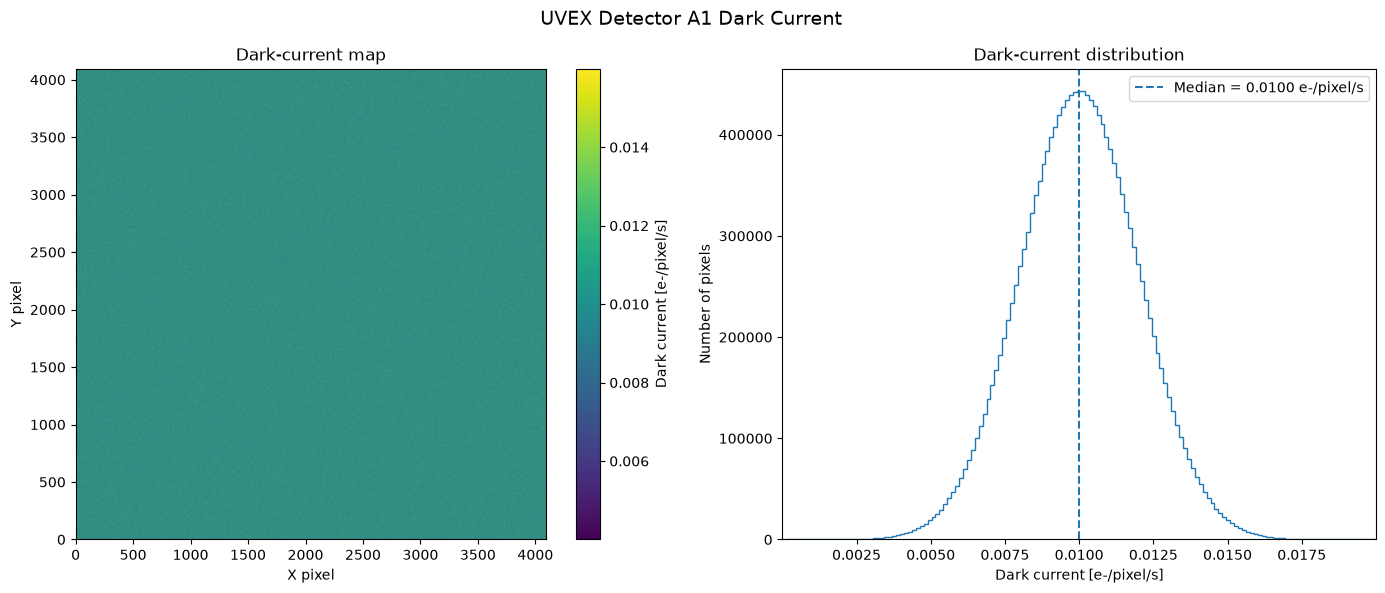

In [9]:
plot_dark_current_map(
    dark_current_map,
    detector_id=DET_ID
)

In [10]:
print("Min:   ", np.min(dark_current_map))
print("Max:   ", np.max(dark_current_map))
print("Mean:  ", np.mean(dark_current_map))
print("Median:", np.median(dark_current_map))
print("Std:   ", np.std(dark_current_map))

Min:    0.0
Max:    0.020623682
Mean:   0.009999704
Median: 0.009999456
Std:    0.0019995687
